In [2]:
import os
import cv2
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

In [3]:
# Data Loading
train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
train_tuple = []

In [4]:
class MyDataLoader():
    def make_training_data(self):
        print("Loading image pairs...")
        for f in tqdm(os.listdir(train_folder_path_x)):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)
            image_x = cv2.imread(image_path_x)
            image_y = cv2.imread(image_path_y)
            if image_x is not None and image_y is not None:
                # Resize to ensure consistent dimensions
                image_x = cv2.resize(image_x, (128, 128))
                image_y = cv2.resize(image_y, (512, 512))
                train_tuple.append((image_x, image_y))
        print(f"Successfully loaded {len(train_tuple)} image pairs")
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

Loading image pairs...


100%|██████████| 900/900 [00:28<00:00, 31.59it/s]

Successfully loaded 900 image pairs


In [5]:
# k-NN Super-Resolution with optimized patch processing
class KNNSuperResolver:
    def __init__(self, k=5, patch_size=5, scale=4):
        self.k = k
        self.patch_size = patch_size
        self.scale = scale
        self.stride = max(1, patch_size // 2)  # Overlapping patches
        
    def extract_patches(self, lr_img, hr_img):
        """Extract patches from image pairs with proper scaling"""
        lr_patches = []
        hr_patches = []
        
        for i in range(0, lr_img.shape[0] - self.patch_size + 1, self.stride):
            for j in range(0, lr_img.shape[1] - self.patch_size + 1, self.stride):
                # Extract LR patch and corresponding HR region
                lr_patch = lr_img[i:i+self.patch_size, j:j+self.patch_size]
                hr_patch = hr_img[self.scale*i:self.scale*(i+self.patch_size), 
                                 self.scale*j:self.scale*(j+self.patch_size)]
                
                # Convert to YCbCr and use Y channel (luminance) for better results
                lr_y = cv2.cvtColor(lr_patch, cv2.COLOR_BGR2YCrCb)[:, :, 0]
                hr_y = cv2.cvtColor(hr_patch, cv2.COLOR_BGR2YCrCb)[:, :, 0]
                
                lr_patches.append(lr_y.flatten())
                hr_patches.append(hr_y.flatten())
                
        return np.array(lr_patches), np.array(hr_patches)

    def reconstruct_image(self, lr_img, knn_model):
        """Reconstruct HR image using trained KNN model"""
        hr_shape = (lr_img.shape[0]*self.scale, lr_img.shape[1]*self.scale)
        hr_reconstructed = np.zeros(hr_shape, dtype=np.float32)
        count = np.zeros(hr_shape, dtype=np.float32)
        
        for i in range(0, lr_img.shape[0] - self.patch_size + 1, self.stride):
            for j in range(0, lr_img.shape[1] - self.patch_size + 1, self.stride):
                # Process Y channel
                lr_patch = cv2.cvtColor(
                    lr_img[i:i+self.patch_size, j:j+self.patch_size], 
                    cv2.COLOR_BGR2YCrCb
                )[:, :, 0].flatten()
                
                # Predict HR patch
                hr_pred = knn_model.predict([lr_patch])[0]
                hr_pred = hr_pred.reshape((self.patch_size*self.scale, self.patch_size*self.scale))
                
                # Place predicted patch
                start_i, start_j = self.scale*i, self.scale*j
                end_i, end_j = start_i+self.patch_size*self.scale, start_j+self.patch_size*self.scale
                hr_reconstructed[start_i:end_i, start_j:end_j] += hr_pred
                count[start_i:end_i, start_j:end_j] += 1
        
        # Average overlapping regions and convert back to BGR
        hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)

# Simple upsampling for chroma channels (for faster processing)
        hr_cbcr = cv2.resize(
            cv2.cvtColor(lr_img, cv2.COLOR_BGR2YCrCb)[:, :, 1:], 
            (hr_shape[1], hr_shape[0]), 
            interpolation=cv2.INTER_LINEAR
        )
        
        # Merge channels and convert back to BGR
        hr_reconstructed = cv2.cvtColor(
            np.dstack((hr_y, hr_cbcr)), 
            cv2.COLOR_YCrCb2BGR
        )
        
        return hr_reconstructed
        

In [6]:
# Evaluation function with parallel processing
def evaluate_knn_samples(sample_indices, k_values, patch_size=5):
    results = []
    
    for idx in sample_indices:
        lr_img, hr_img = train_tuple[idx]
        
        for k in k_values:
            print(f"\nProcessing sample {idx} with k={k}")
            
            # Initialize resolver
            resolver = KNNSuperResolver(k=k, patch_size=patch_size)
            
            # Extract patches and train KNN
            lr_patches, hr_patches = resolver.extract_patches(lr_img, hr_img)
            knn = KNeighborsRegressor(n_neighbors=k, weights='distance', n_jobs=-1)
            knn.fit(lr_patches, hr_patches)
            
            # Reconstruct image
            hr_pred = resolver.reconstruct_image(lr_img, knn)
            
            # Calculate metrics
            psnr_val = peak_signal_noise_ratio(hr_img, hr_pred)
            ssim_val = structural_similarity(hr_img, hr_pred, channel_axis=-1)
            results.append((idx, k, psnr_val, ssim_val))
            
            # Visualization
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Low Resolution\n{lr_img.shape[1]}x{lr_img.shape[0]}")

            plt.subplot(1, 3, 2)
            plt.imshow(cv2.cvtColor(hr_pred, cv2.COLOR_BGR2RGB))
            plt.title(f"k-NN (k={k}) Upscaled\n{hr_pred.shape[1]}x{hr_pred.shape[0]}\nPSNR: {psnr_val:.2f} dB")
            
            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Original High Resolution\n{hr_img.shape[1]}x{hr_img.shape[0]}")
            
            plt.tight_layout()
            plt.show()
    
    return results


Processing sample 0 with k=3


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


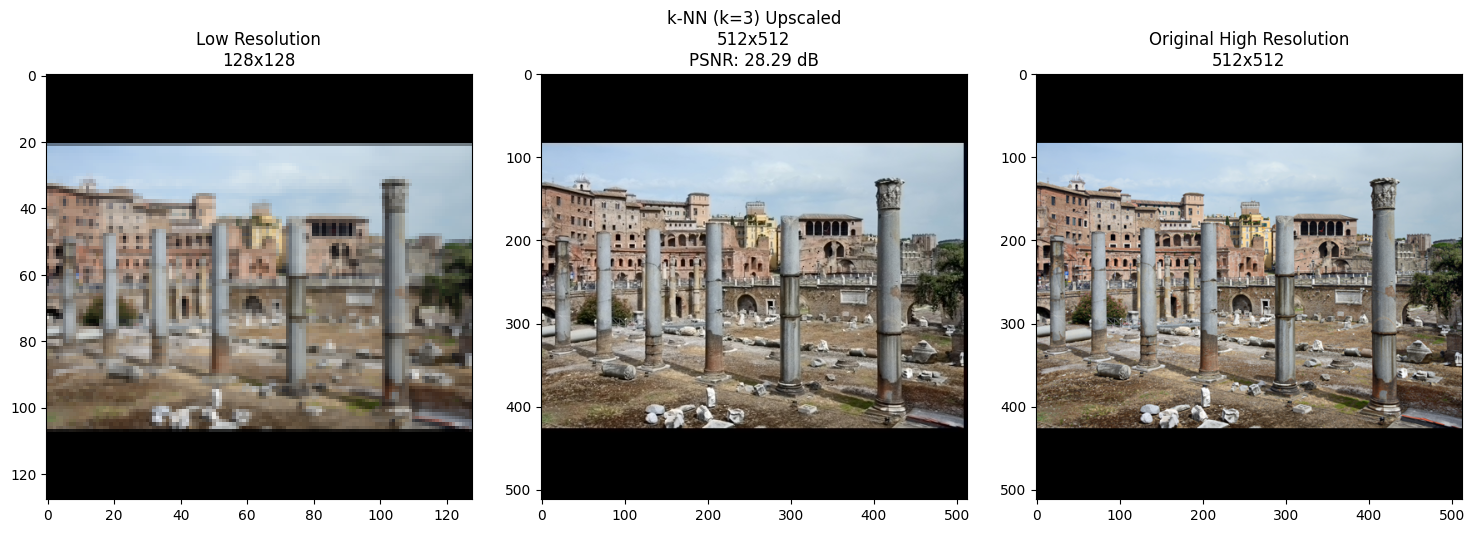


Processing sample 0 with k=5


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


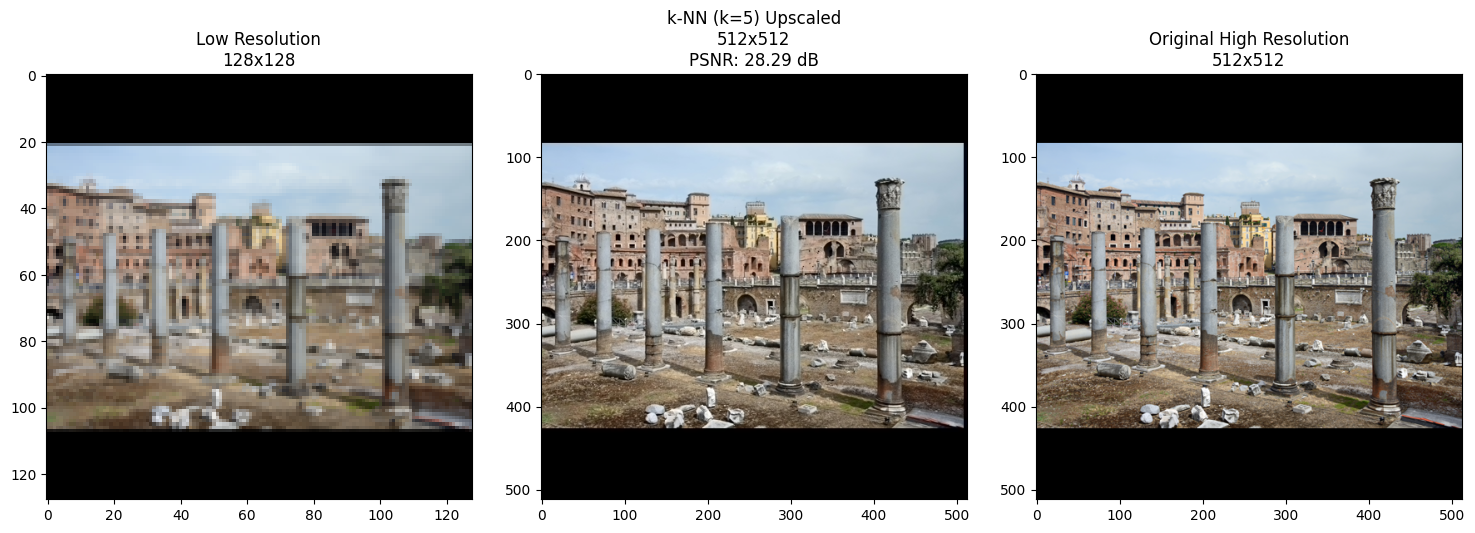


Processing sample 0 with k=7


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


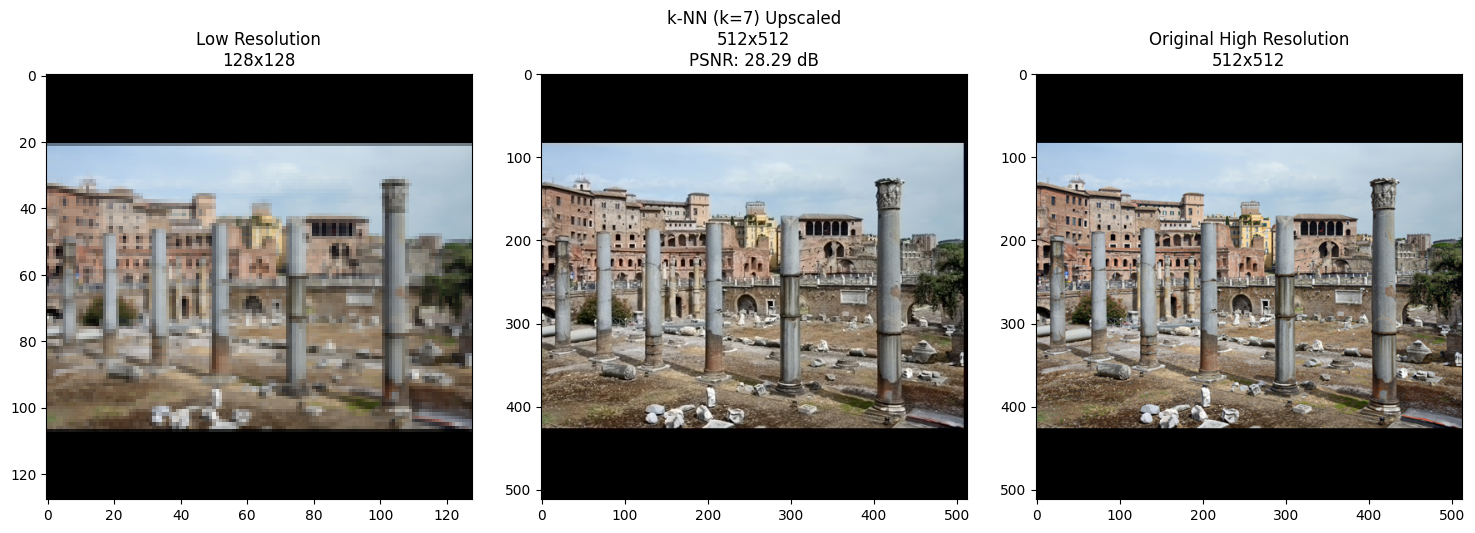


Processing sample 10 with k=3


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


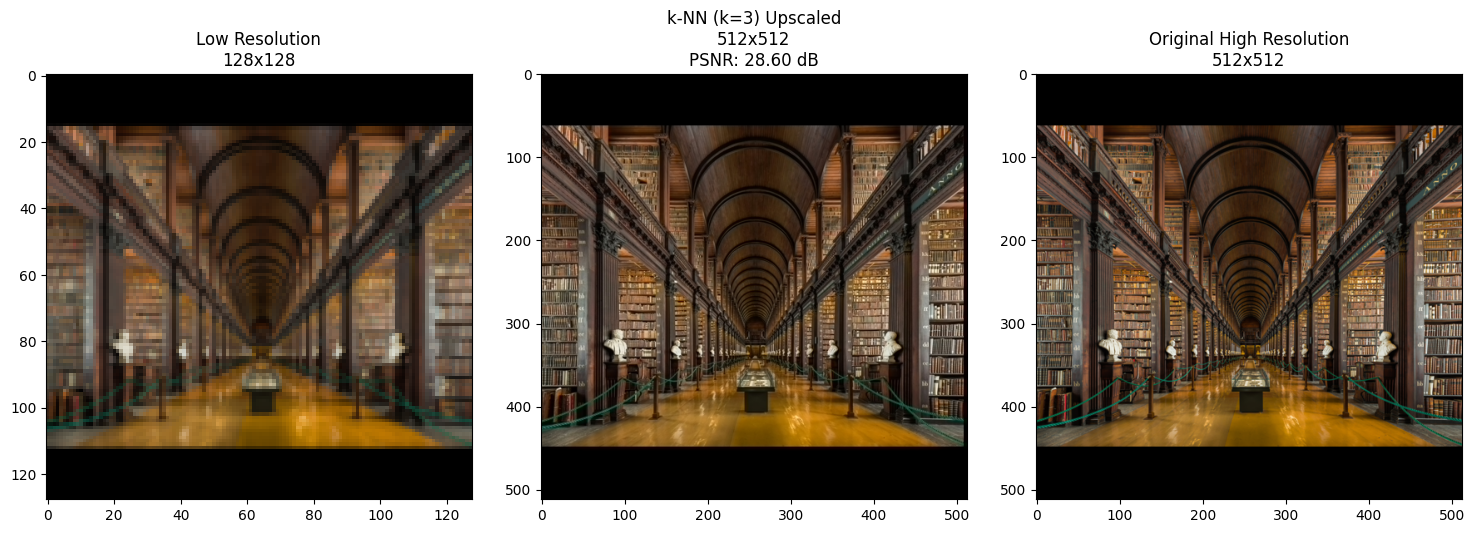


Processing sample 10 with k=5


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


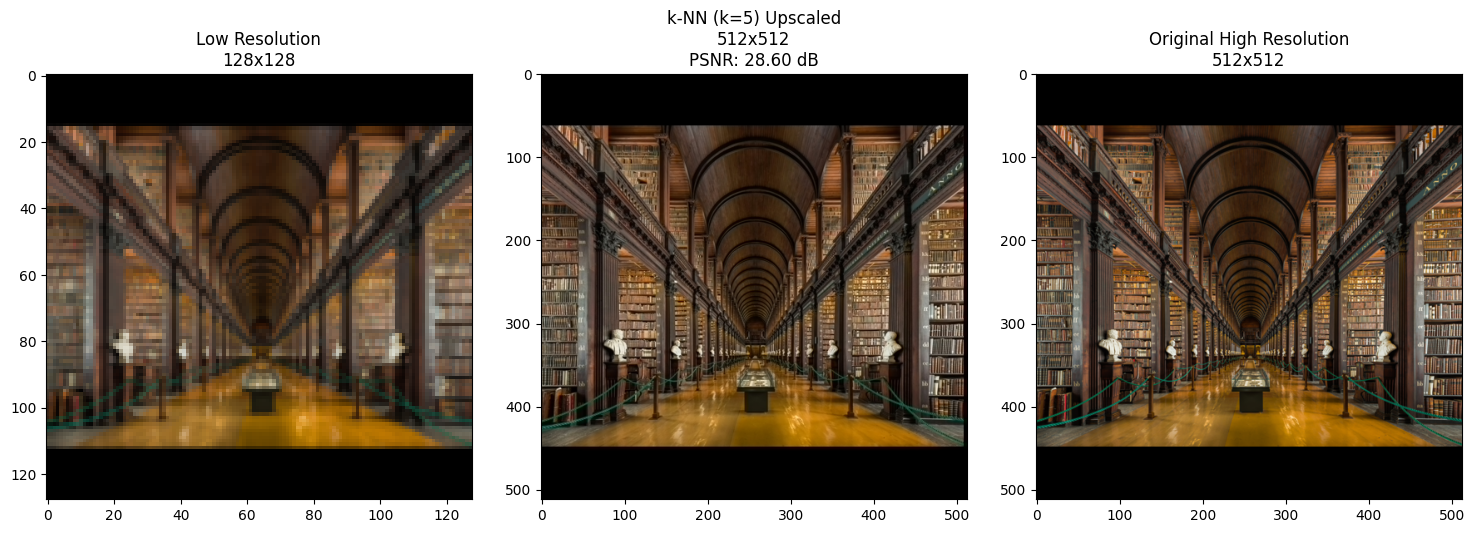


Processing sample 10 with k=7


<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: divide by zero encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in divide
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)
<ipython-input-5-9c5c2726b1a0>:55: RuntimeWarning: invalid value encountered in cast
  hr_y = (hr_reconstructed / count).clip(0, 255).astype(np.uint8)


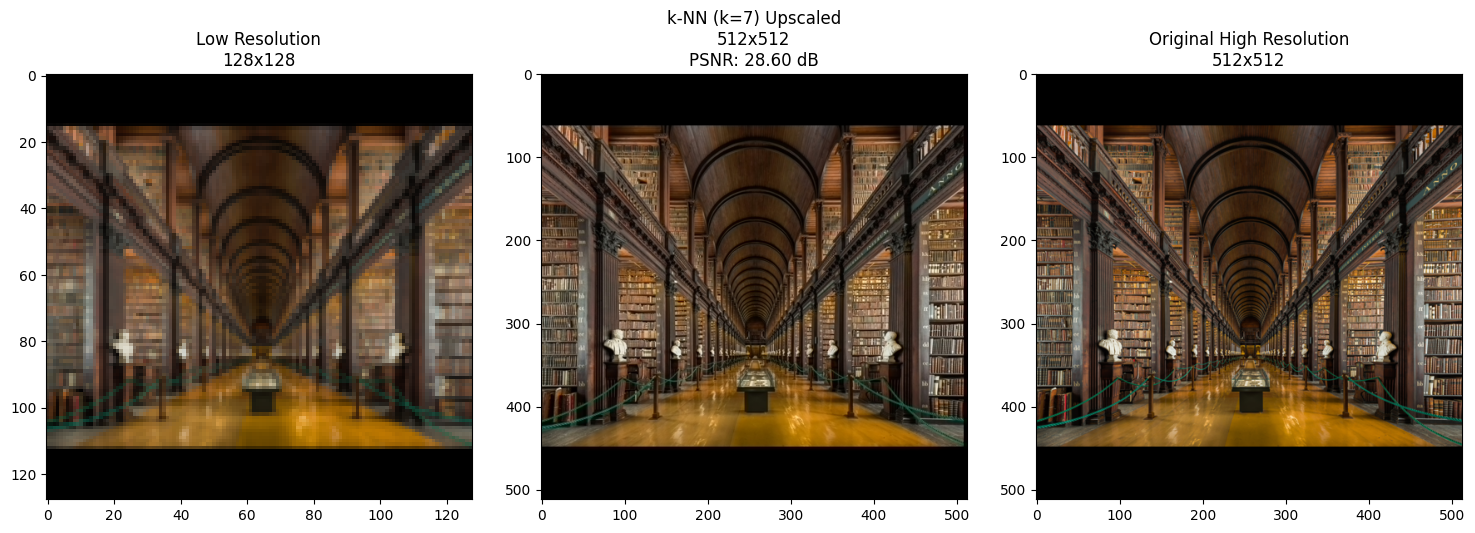

In [9]:
# Configuration
sample_indices = [0, 10]  # Samples to evaluate
k_values = [3, 5, 7]          # Different k values to try
patch_size = 5                # Patch size for feature extraction

# Run evaluation
results = evaluate_knn_samples(sample_indices, k_values, patch_size)

In [10]:
# Print summary
print("\nPerformance Summary:")
print("Sample\tk\tPSNR (dB)\tSSIM")
print("-"*40)
for r in results:
    print(f"{r[0]}\t{r[1]}\t{r[2]:.2f}\t\t{r[3]:.4f}")

# Additional analysis
avg_psnr = np.mean([r[2] for r in results])
avg_ssim = np.mean([r[3] for r in results])
print("\nAverage across all samples:")
print(f"PSNR: {avg_psnr:.2f} dB")
print(f"SSIM: {avg_ssim:.4f}")


Performance Summary:
Sample	k	PSNR (dB)	SSIM
----------------------------------------
0	3	28.29		0.9832
0	5	28.29		0.9832
0	7	28.29		0.9832
10	3	28.60		0.9463
10	5	28.60		0.9463
10	7	28.60		0.9463

Average across all samples:
PSNR: 28.45 dB
SSIM: 0.9647
